# 3e

For initial condition where x3(0) = 100, and all other indexes of x(0) are 0, the 3rd mode which corresponds with the $\pm .0011i$ eigenvalues is excited. Since we have imaginary eigenvalues, we expect oscillatory motion in the third mode (x3 will follow an oscillatory pattern). Notice that per matrix $A$, x3 only affects x6 through a decoupled system: 

$$
\dot{x_3} = x_6
$$

$$ 
\dot{x_6} = -n^2 x_3
$$

So, $\dot{\dot{x_3}} + n^2 x_3 = 0 $ which is a simple harmonic oscillator ($x_3$ oscillates). Through simple ODE methods, we know $x_3(t) = A cos(nt) + B sin(nt)$ so the sixth state, which is the time derivative of the 3rd state, is: $x_6 = -An sin(nt)  + Bn cos(nt)$. Thus, we expect oscillation in x_3 and x_6. Since the initial condition is $x_3(0) = 100$ and $x_6(0) = 0 $ , we have:
$x_3(t) = 100 cos(nt) $ and $x_6(t) = -100n sin(nt)$. Since $n = .0013 Hz$, we expect the magnitude of oscillation to be about 1/1000 th of the magnitude of oscillation for $x_3(t)$. Since $x_3$ and $x_6$ are cosine/sine components, they will remain oscillatory and finite for all time $t \ge 0$.

$x_1$, $x_2$, $\dot{x}_1$, $\dot{x}_2$ will remain identically zero for all time because they are not excited by the initial condition. The dynamics for these states are homogeneous and decoupled from $x_3$, and with zero initial conditions, they have no reason to become nonzero.

Thus the only non-zero components are $x_3$ and $x_6$ which are bounded, so the system remains finite for all $t \ge 0$

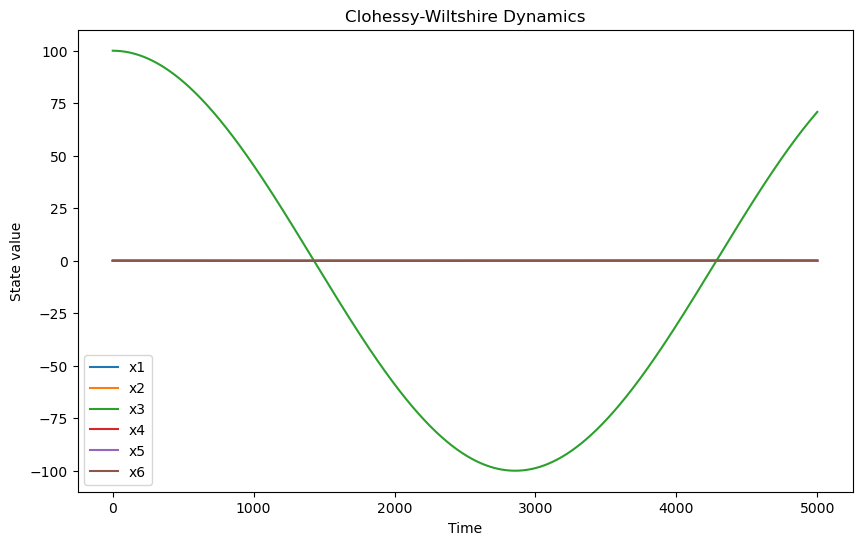

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Orbital rate
n = 0.0011  # approximate value from J

# Define J
J = np.array([
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, -1j*n, 0, 0, 0],
    [0, 0, 0, 1j*n, 0, 0],
    [0, 0, 0, 0, -1j*n, 0],
    [0, 0, 0, 0, 0, 1j*n]
], dtype=complex)

# Q matrix
Q = np.array([
    [0, 4, -1.5, -1.5, 0, 0],
    [-0.0068, 0, 3j, -3j, 0, 0],
    [0, 0, 0, 0, 0.5, 0.5],
    [0, 0, 0.0017j, -0.0017j, 0, 0],
    [0, -0.0068, 0.0034, 0.0034, 0, 0],
    [0, 0, 0, 0, -0.0006j, 0.0006j]
], dtype=complex)

Qinv = np.linalg.inv(Q)

# Initial condition
x0 = np.array([0, 0, 100, 0, 0, 0], dtype=complex)

# Time vector
t = np.linspace(0, 5000, 2000)

x = np.zeros((6, len(t)), dtype=complex)

for i, ti in enumerate(t):
    expJt = expm(J * ti)
    x[:, i] = Q @ expJt @ Qinv @ x0

x_real = np.real(x)

# Plot all states
plt.figure(figsize=(10,6))
for i in range(6):
    plt.plot(t, x_real[i,:], label=f"x{i+1}")
plt.legend()
plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Clohessy-Wiltshire Dynamics")
plt.show()



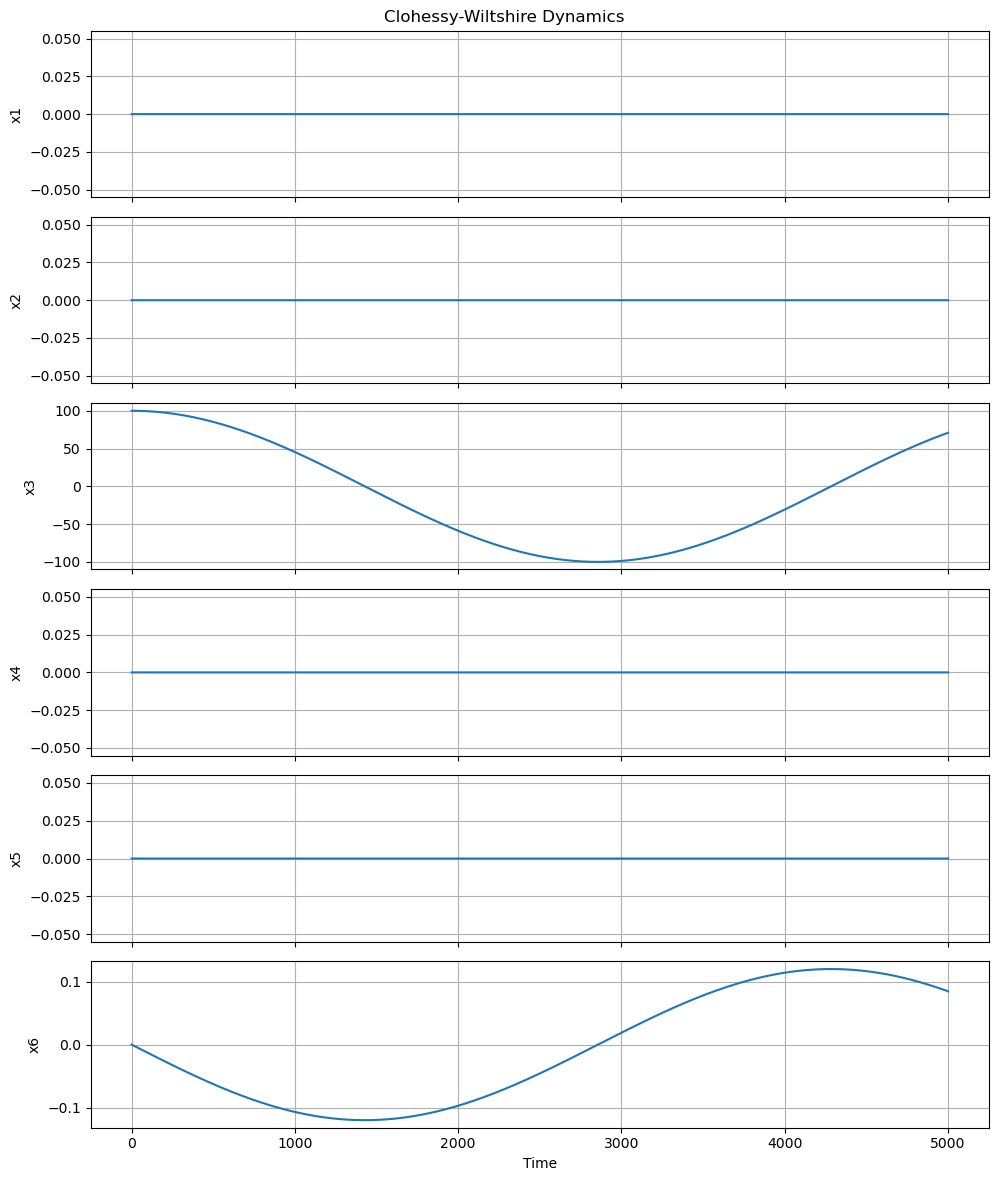

In [7]:
fig, axs = plt.subplots(6, 1, figsize=(10, 12), sharex=True)

for i in range(6):
    axs[i].plot(t, x_real[i, :])
    axs[i].set_ylabel(f"x{i+1}")
    axs[i].grid(True)

axs[-1].set_xlabel("Time")
fig.suptitle("Clohessy-Wiltshire Dynamics")
plt.tight_layout()
plt.show()


In part (d), we concluded the system is not internally stable due to the Jordan block (polynomial growth).

In part (e), for the specific initial condition $x(0) = (0,0,100,0,0,0)$, the state appears to remain bounded (just oscillation in $x_3$ and $x_6$).

This is not a contradiction.

Internal stability (or asymptotic stability) requires that for all initial conditions, the state remains bounded/finite. A single counterexample of an initial condition that produces unbounded growth is enough to declare the system internally unstable.

In part (e), we have chosen a  specific initial condition that lies entirely in the stable subspace of the system—specifically, it excites only the oscillatory out-of-plane modes while completely avoiding the unstable Jordan block. 

The Jordan block $\begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ in $J$ corresponds to modes that grow linearly in time ($t^1$ growth). For an initial condition with any nonzero component in the direction of these modes, the state would grow without bound.

Therefore:

The system is internally unstable because there exists at least one initial condition (e.g., those exciting the Jordan block) that lead to unbounded growth.

The particular initial condition in (e) happens to be in the stable manifold—a set of measure zero in the state space—and thus produces bounded motion.

